In [36]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load MNIST Handwritten Digit Recognition Datasets

In [37]:
(X_train, y_train), (X_test, y_test)= keras.datasets.mnist.load_data()

In [38]:
X_train.shape

(60000, 28, 28)

# 2. Visualization of sample data

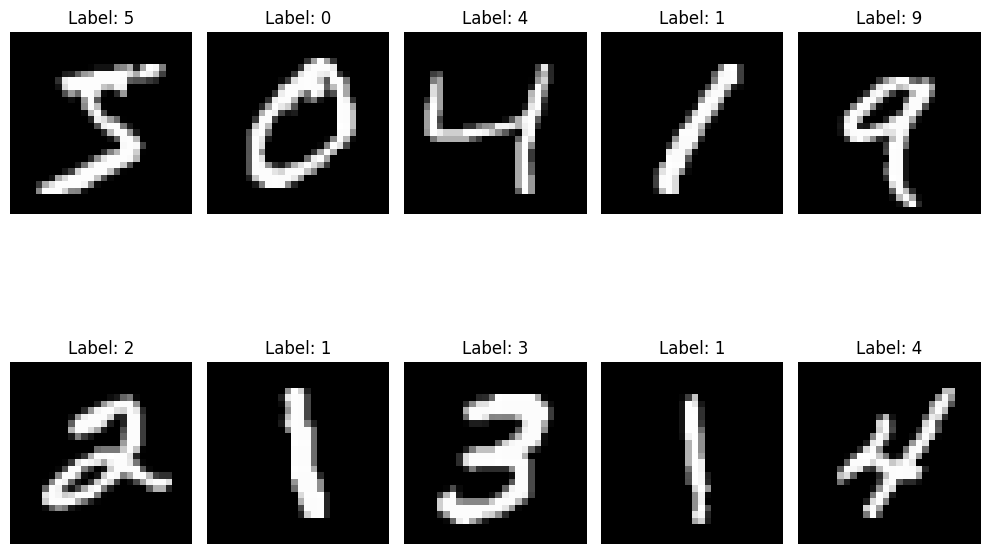

In [39]:
plt.figure(figsize= (10,8))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# 3. Data Preprocssing

In [40]:
X_train= X_train.reshape(60000, 28*28).astype('float32')/255
X_test= X_test.reshape(10000, 28*28).astype('float32')/255

In [41]:
X_train.shape

(60000, 784)

In [42]:
X_test.shape

(10000, 784)

# 4.Build ANN Model

In [43]:
# hidden layers -> use relu
# output layer -> use sigmoid(for binary classification) or softmax(for multiclass classification)

model= keras.Sequential([
    layers.Dense(512, activation= 'relu', input_shape=(784,)),
    layers.Dense(256, activation= 'relu'),
    layers.Dense(128, activation= 'relu'),
    layers.Dense(10, activation= 'softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.compile(
    optimizer= 'adam',
    loss= 'sparse_categorical_crossentropy',
    metrics= ['accuracy']
)

In [45]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history= model.fit(
    X_train, y_train,
    epochs= 10,
    batch_size= 32,
    validation_split= 0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9338 - loss: 0.2165 - val_accuracy: 0.9567 - val_loss: 0.1348
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9720 - loss: 0.0929 - val_accuracy: 0.9697 - val_loss: 0.1039
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9799 - loss: 0.0657 - val_accuracy: 0.9707 - val_loss: 0.1063
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9841 - loss: 0.0498 - val_accuracy: 0.9737 - val_loss: 0.0932
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9872 - loss: 0.0407 - val_accuracy: 0.9746 - val_loss: 0.0926
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9886 - loss: 0.0344 - val_accuracy: 0.9757 - val_loss: 0.0985
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9907 - loss: 0.0289 - val_accuracy: 0.9788 - val_loss: 0.0878
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9916 - loss: 0.0260 - 

# 5.Training Visualization

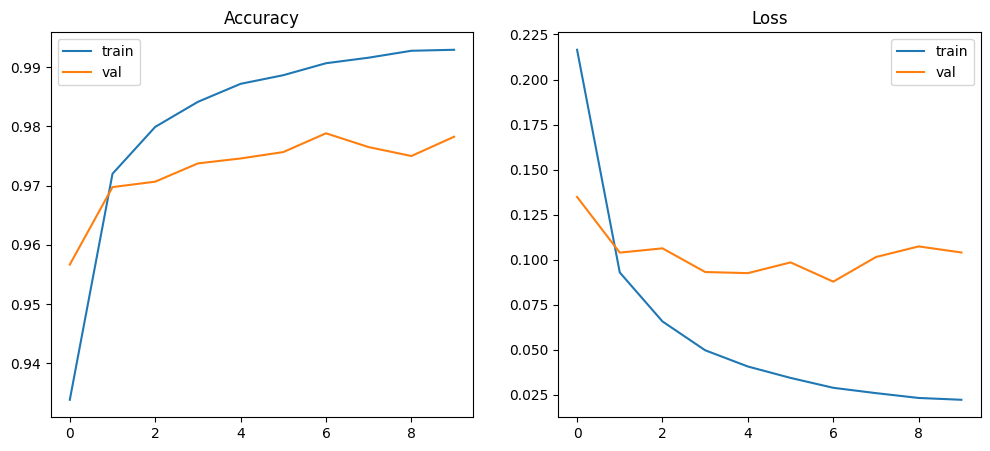

In [47]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

# 6. Predictions Visualization

In [48]:
predictions= model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


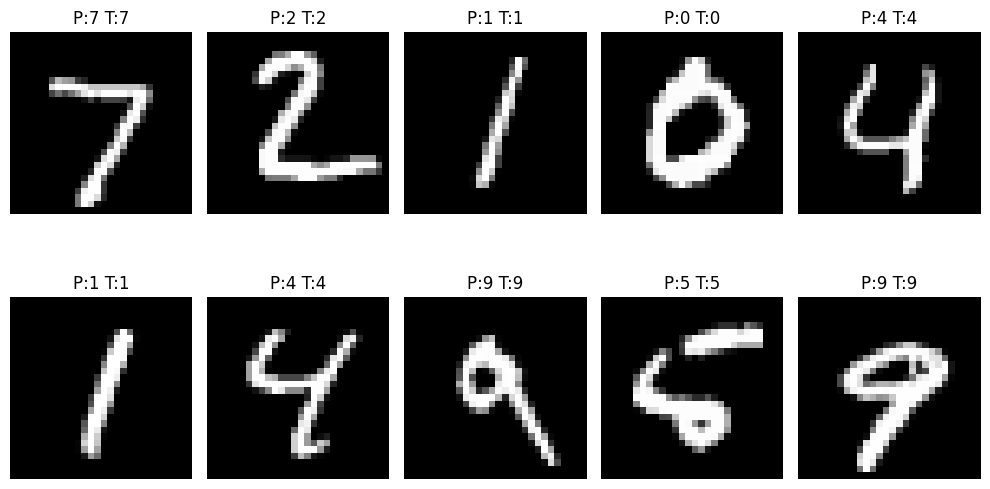

In [49]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    plt.title(f"P:{pred_label} T:{true_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 7.Model Evaluate

In [50]:
test_loss, test_acc= model.evaluate(X_test, y_test)
print('Test Accuracy: ', test_acc)
print('Test Loss: ', test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9813 - loss: 0.0918
Test Accuracy:  0.9812999963760376
Test Loss:  0.09182197600603104


In [51]:
y_pred= np.argmax(predictions, axis=1)

print('Classification Report: \n')
print(classification_report(y_test, y_pred))

Classification Report: 

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.99      0.97      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.99      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.95      0.99      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

